<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/V-Dem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar de datos

In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [2]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [3]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro-2011-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2011_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2011_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2011_eng.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2011_esp.dta  
Archive:  latinobarometro/latinobarometro-1998-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_1998_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1998_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1998_datos_english_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_1998_datos_esp_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2018-eng-stata-v20190303.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2018_Eng_Stata_v20190303.dta  
Archive:  latinobarometro/latinobarometro-2001-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2001_Esp.pdf  
  inflating: latin

In [4]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
},

# ---------------------------------
# Confianza en el Congreso
# ---------------------------------

"confianza_congreso": {
    1995: "p27i",
    1996: "p33i",
    1997: "sp63f",
    1998: "sp38f",
    2000: "P35ST_F",
    2001: "p61stf",
    2002: "p36std",
    2003: "p21stf",
    2004: "p34stf",
    2005: "p45sta",
    2006: "p24st_f",
    2007: "p24st_f",
    2008: "p28st_a",
    2009: "p26st_a",
    2010: "P20ST_A",
    2011: "P22ST_A",
    2013: "P26TGB_C",
    2015: "P16ST_F",
    2016: "P13STD",
    2017: "P14ST_D",
    2018: "P15STGBSC.D",
    2020: "p13st_d",
    2023: "P13ST_D",
    2024: "P14ST.D"
},

# ---------------------------------
# Confianza en el Gobierno
# ---------------------------------

"confianza_gobierno": {
    1995: "p27m",
    1996: "p33m",
    2002: "p34std",
    2003: "p23stg",
    2004: "p32std",
    2005: "p45stc",
    2006: "p32st_a",
    2007: "p24st_a",
    2008: "p31s_ta",
    2009: "p24st_a",
    2010: "P18ST_A",
    2011: "P20ST_A",
    2013: "P26TGB_B",
    2015: "P16ST_G",
    2016: "P13STE",
    2017: "P14ST_E",
    2018: "P15STGBSC.E",
    2020: "p13st_e",
    2023: "P13ST_E",
    2024: "P14ST.E"
},

# ---------------------------------
# Confianza en el Poder Judicial
# ---------------------------------

"confianza_judicial": {
    1995: "p27d",
    1996: "p33d",
    1997: "sp63c",
    1998: "sp38c",
    2000: "P35ST_C",
    2001: "p61stc",
    2002: "p34stc",
    2003: "p21ste",
    2004: "p34stb",
    2005: "p42std",
    2006: "p24st_a",
    2007: "p24st_d",
    2008: "p28st_b",
    2009: "p26st_b",
    2010: "P20ST_B",
    2011: "P22ST_B",
    2013: "P26TGB_E",
    2015: "P16ST_H",
    2016: "P13STF",
    2017: "P14ST_F",
    2018: "P15STGBSC.F",
    2020: "p13st_f",
    2023: "P13ST_F",
    2024: "P14ST.F"
}


}

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [6]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote",
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Recodificación

In [7]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)


conversion_confianza = {
    4: 1,  # ninguna
    3: 2,  # poca
    2: 3,  # algo
    1: 4   # mucha confianza
}

master["confianza_congreso"] = (
    master["confianza_congreso"]
    .map(conversion_confianza)
)

master["confianza_gobierno"] = (
    master["confianza_gobierno"]
    .map(conversion_confianza)
)

master["confianza_judicial"] = (
    master["confianza_judicial"]
    .map(conversion_confianza)
)

In [8]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

# Confianza institucional es el promedio de congreso, gobierno y judicial.
master["confianza_institucional"] = (
    master[
        [
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]
    ].mean(axis=1)
)

In [9]:
#Eliminamos España
master = master[master['country'] != 724]

# V-Dem

In [10]:
vdem=pd.read_csv('V-Dem-CY-Full+Others-v16.csv')

/tmp/ipykernel_813/1646469836.py:1: DtypeWarning: Columns (364,365,366,399,415,804,836,837,924,1240,1257,1486,3094,3168,3169,3341,3342,3344,3345,3347,3350,3352) have mixed types. Specify dtype option on import or set low_memory=False.
  vdem=pd.read_csv('V-Dem-CY-Full+Others-v16.csv')


In [11]:
country_iso3 = {
    32: 'ARG',
    68: 'BOL',
    76: 'BRA',
    152: 'CHL',
    170: 'COL',
    188: 'CRI',
    214: 'DOM',
    218: 'ECU',
    222: 'SLV',
    320: 'GTM',
    340: 'HND',
    484: 'MEX',
    558: 'NIC',
    591: 'PAN',
    600: 'PRY',
    604: 'PER',
    858: 'URY',
    862: 'VEN'
}

In [12]:
# Crear código ISO3 en master
master['iso3'] = master['country'].map(country_iso3)

# Seleccionar las variables necesarias de V-Dem
vdem_camps = vdem[['country_text_id', 'year', 'v2cacamps']].copy()

# Renombrar para que las claves sean iguales
vdem_camps = vdem_camps.rename(columns={
    'country_text_id': 'iso3',
    'year': 'wave'
})

# Merge
master = master.merge(
    vdem_camps,
    on=['iso3', 'wave'],
    how='left'
)

In [13]:
tabla_polarizacion = (
    master
    .groupby(['country', 'wave'], as_index=False)
    .agg(
        polarization_vdem=('v2cacamps', 'first'),
        n=('id', 'count'),
        life_satisfaction=('life_satisfaction', 'mean'),
        polarization_individual=('left_right_distance', 'mean'),
        engagement=('interest_politics', 'mean')
    )
)

tabla_polarizacion.head(20)

,country,wave,polarization_vdem,n,life_satisfaction,polarization_individual,engagement
0,32,1995,-0.025,1200,NaN,1.556220,2.221654
1,32,1996,-0.025,1199,NaN,1.566929,1.887953
2,32,1997,-0.025,1196,2.136860,1.455455,1.942857
3,32,1998,-0.025,1200,NaN,1.572881,1.914696
4,32,2000,-0.025,1200,2.210879,1.463496,2.201174
5,32,2001,-0.025,1200,2.823873,1.461457,1.934343
6,32,2002,-0.025,1200,2.597981,1.693901,NaN
7,32,2003,0.358,1200,2.913591,1.472579,2.076278
8,32,2004,0.358,1200,2.921536,1.388590,2.065272
9,32,2005,0.843,1200,2.937133,1.659066,2.080740


In [14]:
tabla = (
    master
    .groupby(['country', 'wave'])
    .agg(
        happiness=('life_satisfaction', 'mean'),
        engagement=('interest_politics', 'mean'),
        polarization=('v2cacamps', 'first'),
        n=('id', 'count')
    )
    .reset_index()
)

In [15]:
import statsmodels.api as sm

def get_slope(g):
    g = g.dropna(subset=['life_satisfaction', 'interest_politics'])

    if len(g) < 30:
        return np.nan

    X = sm.add_constant(g['interest_politics'])
    model = sm.OLS(g['life_satisfaction'], X).fit()

    return model.params['interest_politics']

In [16]:
slopes = (
    master
    .groupby(['country', 'wave'])
    .apply(get_slope)
    .reset_index(name='engagement_happiness_slope')
)

tabla = tabla.merge(
    slopes,
    on=['country', 'wave'],
    how='left'
)

/tmp/ipykernel_813/3072191226.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_slope)


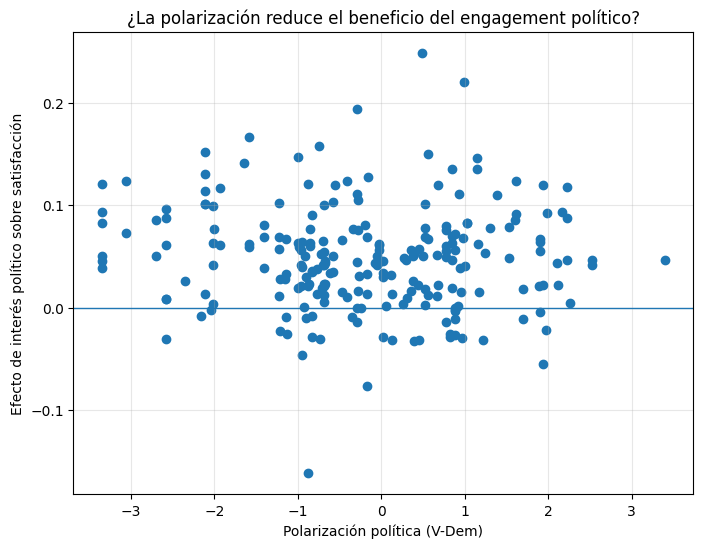

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    tabla['polarization'],
    tabla['engagement_happiness_slope']
)

plt.axhline(0, linewidth=1)

plt.xlabel('Polarización política (V-Dem)')
plt.ylabel('Efecto de interés político sobre satisfacción')
plt.title('¿La polarización reduce el beneficio del engagement político?')

plt.grid(alpha=0.3)
plt.show()

# Modelos

In [37]:
master['polarization_vdem']=master['v2cacamps']
master['polarizacion_ind']=master['left_right_distance']

vars_z = [
     "life_satisfaction","interest_politics", "polarization_vdem","education" , "econ_country", "confianza_institucional", "polarizacion_ind"
    ]

for v in vars_z:
    master[f"{v}_z"] = np.nan

for wave in master["wave"].unique():
    mask = master["wave"] == wave
    for v in vars_z:
        if v in master.columns:
            s = master.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            master.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

In [38]:
vars_modelo = [
    'life_satisfaction_z',
    'interest_politics_z',
    'polarization_vdem_z',
    'sex',
    'age',
    'education_z',
    'confianza_institucional_z',
    'country',
    'wave',
    'econ_country_z',
    'trust_people',
    'polarizacion_ind_z'
]

df_reg = master[vars_modelo].dropna().copy()

print('Observaciones:', len(df_reg))
print('Países:', df_reg['country'].nunique())
print('Años:', df_reg['wave'].nunique())

Observaciones: 191457
Países: 18
Años: 13


In [24]:
# 1. ¿La polarización afecta a la felicidad? No, igual que en Baskin et. al. (2006)

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    life_satisfaction_z ~
    polarization_vdem_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.088
Model:                             OLS   Adj. R-squared:                  0.088
Method:                  Least Squares   F-statistic:                     258.2
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           3.71e-17
Time:                         12:32:58   Log-Likelihood:            -3.2417e+05
No. Observations:               236537   AIC:                         6.484e+05
Df Residuals:                   236501   BIC:                         6.488e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [25]:
# 2. ¿La polarización afecta a la confianza institucional? No. Este resultado difiere

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    confianza_institucional_z ~
    polarization_vdem_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     confianza_institucional_z   R-squared:                       0.144
Model:                                   OLS   Adj. R-squared:                  0.144
Method:                        Least Squares   F-statistic:                     1320.
Date:                       Thu, 13 Aug 2026   Prob (F-statistic):           3.68e-23
Time:                               12:33:13   Log-Likelihood:            -3.1646e+05
No. Observations:                     236537   AIC:                         6.330e+05
Df Residuals:                         236501   BIC:                         6.334e+05
Df Model:                                 35                                         
Covariance Type:                     cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [26]:
# 3. ¿La polarización afecta al interés en política? Si. Positivamente, más polarización más interés

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    interest_politics_z ~
    polarization_vdem_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     interest_politics_z   R-squared:                       0.069
Model:                             OLS   Adj. R-squared:                  0.068
Method:                  Least Squares   F-statistic:                 2.996e+04
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           1.11e-34
Time:                         12:33:22   Log-Likelihood:            -3.2719e+05
No. Observations:               236537   AIC:                         6.545e+05
Df Residuals:                   236501   BIC:                         6.548e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [27]:
# ¿La confianza institucional afecta la felicidad? Si, igual que en Baskin et. al. (2006)

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    life_satisfaction_z ~
    confianza_institucional_z
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.092
Model:                             OLS   Adj. R-squared:                  0.091
Method:                  Least Squares   F-statistic:                     519.4
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           1.01e-19
Time:                         12:34:02   Log-Likelihood:            -3.2376e+05
No. Observations:               236537   AIC:                         6.476e+05
Df Residuals:                   236501   BIC:                         6.480e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept   

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [28]:
# ¿El interés en política afecta a la felicidad? Si

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    life_satisfaction_z ~
    interest_politics_z
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.089
Model:                             OLS   Adj. R-squared:                  0.089
Method:                  Least Squares   F-statistic:                     1353.
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           3.00e-23
Time:                         12:34:08   Log-Likelihood:            -3.2414e+05
No. Observations:               236537   AIC:                         6.484e+05
Df Residuals:                   236501   BIC:                         6.487e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [29]:
# ¿La polarización baja la incidencia del interés en felicidad? No

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    life_satisfaction_z ~
    interest_politics_z * polarization_vdem_z
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.089
Model:                             OLS   Adj. R-squared:                  0.089
Method:                  Least Squares   F-statistic:                     345.4
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           3.17e-18
Time:                         12:34:21   Log-Likelihood:            -3.2412e+05
No. Observations:               236537   AIC:                         6.483e+05
Df Residuals:                   236499   BIC:                         6.487e+05
Df Model:                           37                                         
Covariance Type:               cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 17
  warnings.warn('covariance of constraints does not have full '


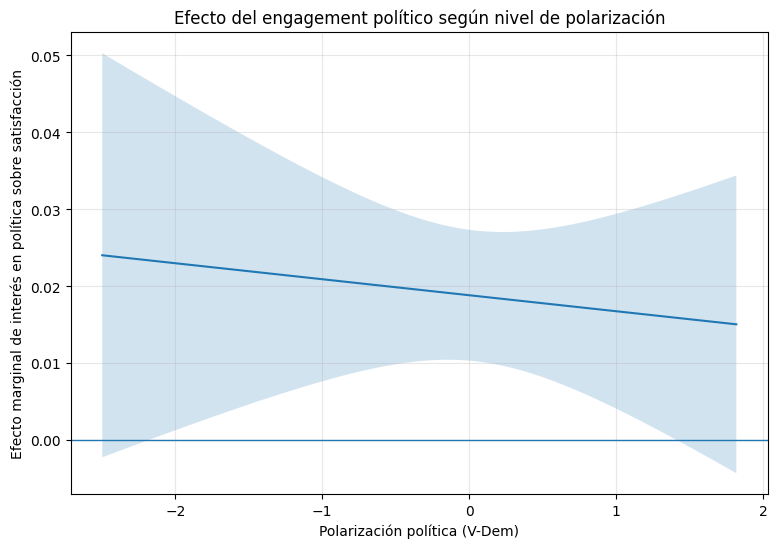

In [36]:
import numpy as np
import matplotlib.pyplot as plt

beta1 = model.params['interest_politics_z']
beta3 = model.params['interest_politics_z:polarization_vdem_z']

vcov = model.cov_params()

var_b1 = vcov.loc['interest_politics_z', 'interest_politics_z']
var_b3 = vcov.loc[
    'interest_politics_z:polarization_vdem_z',
    'interest_politics_z:polarization_vdem_z'
]
cov_b1b3 = vcov.loc[
    'interest_politics_z',
    'interest_politics_z:polarization_vdem_z'
]

pol = np.linspace(
    df_reg['polarization_vdem_z'].min(),
    df_reg['polarization_vdem_z'].max(),
    100
)

marginal = beta1 + beta3 * pol

se = np.sqrt(
    var_b1
    + pol**2 * var_b3
    + 2 * pol * cov_b1b3
)

ci_low = marginal - 1.96 * se
ci_high = marginal + 1.96 * se

plt.figure(figsize=(9, 6))

plt.plot(pol, marginal)
plt.fill_between(pol, ci_low, ci_high, alpha=0.2)

plt.axhline(0, linewidth=1)

plt.xlabel('Polarización política (V-Dem)')
plt.ylabel('Efecto marginal de interés en política sobre satisfacción')
plt.title('Efecto del engagement político según nivel de polarización')

plt.grid(alpha=0.3)
plt.show()

# Polarización individual

In [40]:
# ¿La polarización INDIVIDUAL afecta a la felicidad? Si. Este resultado difiere

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    life_satisfaction_z ~
    polarizacion_ind_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     life_satisfaction_z   R-squared:                       0.085
Model:                             OLS   Adj. R-squared:                  0.085
Method:                  Least Squares   F-statistic:                 2.050e+05
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           8.85e-42
Time:                         12:42:27   Log-Likelihood:            -2.6193e+05
No. Observations:               191457   AIC:                         5.239e+05
Df Residuals:                   191421   BIC:                         5.243e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [41]:
# 2. ¿La polarización INDIVIDUAL afecta a la confianza institucional? Si, pero positivamente.

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    confianza_institucional_z ~
    polarizacion_ind_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                                OLS Regression Results                               
Dep. Variable:     confianza_institucional_z   R-squared:                       0.148
Model:                                   OLS   Adj. R-squared:                  0.147
Method:                        Least Squares   F-statistic:                     2737.
Date:                       Thu, 13 Aug 2026   Prob (F-statistic):           7.55e-26
Time:                               12:44:21   Log-Likelihood:            -2.5554e+05
No. Observations:                     191457   AIC:                         5.111e+05
Df Residuals:                         191421   BIC:                         5.115e+05
Df Model:                                 35                                         
Covariance Type:                     cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [42]:
# 3. ¿La polarización INDIVIDUAL afecta al interés en política? Si. Positivamente, más polarización más interés

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    interest_politics_z ~
    polarizacion_ind_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     interest_politics_z   R-squared:                       0.062
Model:                             OLS   Adj. R-squared:                  0.062
Method:                  Least Squares   F-statistic:                     323.4
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           5.54e-18
Time:                         12:47:56   Log-Likelihood:            -2.6719e+05
No. Observations:               191457   AIC:                         5.345e+05
Df Residuals:                   191421   BIC:                         5.348e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [47]:
# 3. ¿La polarización INDIVIDUAL afecta a la polarización ideológica? No.

import statsmodels.formula.api as smf

model = smf.ols(
    '''
    polarization_vdem_z ~
    polarizacion_ind_z +
    + sex + age + education_z + econ_country_z + trust_people
    + C(country) + C(wave)
    ''',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['country']}
)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     polarization_vdem_z   R-squared:                       0.788
Model:                             OLS   Adj. R-squared:                  0.787
Method:                  Least Squares   F-statistic:                     8837.
Date:                 Thu, 13 Aug 2026   Prob (F-statistic):           3.57e-30
Time:                         13:31:02   Log-Likelihood:            -1.2754e+05
No. Observations:               191457   AIC:                         2.552e+05
Df Residuals:                   191421   BIC:                         2.555e+05
Df Model:                           35                                         
Covariance Type:               cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 17
  warnings.warn('covariance of constraints does not have full '


# Matriz de correlación

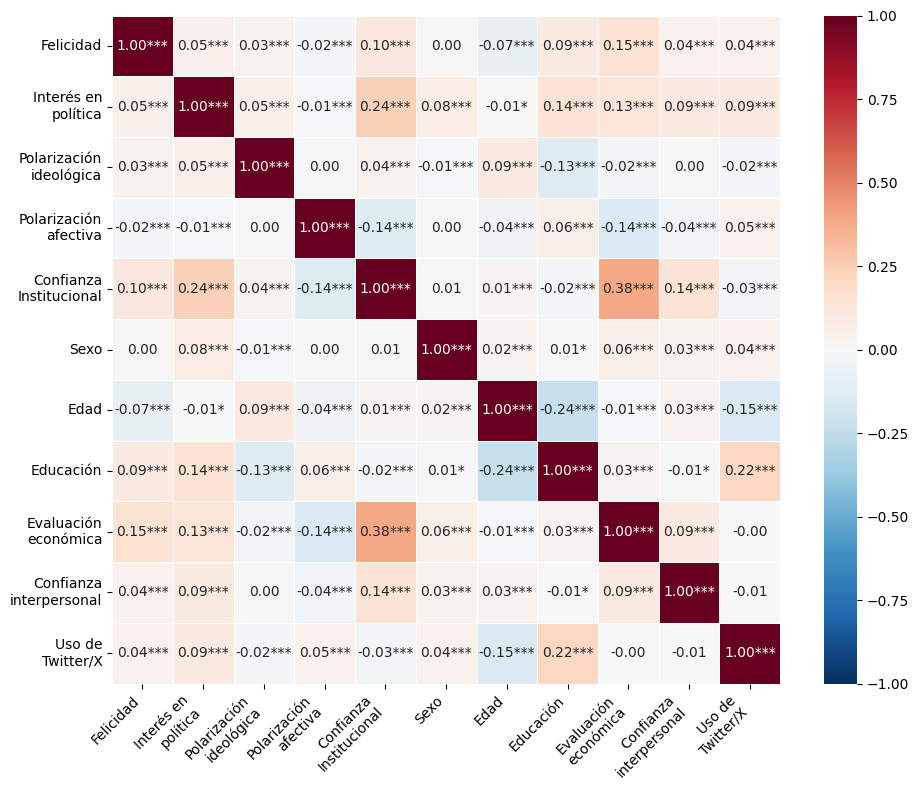

In [46]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

cols = [
    "life_satisfaction",
    "interest_politics",
    "polarizacion_ind",
    "polarization_vdem",
    "confianza_institucional",
    "sex",
    "age",
    "education",
    "econ_country",
    "trust_people",
    "twitter",
]

labels = {
    "life_satisfaction": "Felicidad",
    "interest_politics": "Interés en\npolítica",
    "polarizacion_ind": "Polarización\nideológica",
    "polarization_vdem": "Polarización\nafectiva",
    "confianza_institucional": "Confianza\nInstitucional",
    "sex": "Sexo",
    "age": "Edad",
    "education": "Educación",
    "econ_country": "Evaluación\neconómica",
    "trust_people": "Confianza\ninterpersonal",
    "twitter": "Uso de\nTwitter/X",
}

df_corr = master[cols].dropna()

# Matrices de correlaciones y p-values
corr = pd.DataFrame(index=cols, columns=cols, dtype=float)
pval = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        r, p = pearsonr(df_corr[i], df_corr[j])
        corr.loc[i, j] = r
        pval.loc[i, j] = p

# Renombrar
corr = corr.rename(index=labels, columns=labels)
pval = pval.rename(index=labels, columns=labels)

# Texto de anotación
annot = corr.copy().astype(str)

for i in corr.index:
    for j in corr.columns:
        r = corr.loc[i, j]
        p = pval.loc[i, j]

        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = ""

        annot.loc[i, j] = f"{r:.2f}{sig}"

# Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=annot,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
    annot_kws={"size": 10}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()